# Multivariate linear regression

In this notebook, we will apply linear regression to experimental data relating mix design variables to the compressive strength of high-performance concrete.

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# The dataset is stored in Excel format (.xls).
# Pandas requires the 'xlrd' package to read this format.
# If you get an error, install it via: pip install xlrd

In [109]:
def parity_plot(y_true, y_pred, title="Parity Plot"):
    plt.figure()
    
    # Scatter plot: true vs predicted
    #plt.scatter(y_true, y_pred, s=80, c='k', marker='x', linewidth=0.7, zorder=1)
    hb = plt.hexbin(y_true, y_pred, zorder=-1, cmap='gray_r', mincnt=1, gridsize=12, edgecolors='none')
    #For large datasets, individual scatter points may overlap, making it difficult to assess the distribution of predictions. 
    # Hexagonal binning addresses this issue by grouping points into bins and visualizing their frequency through color intensity. 
    # The associated colorbar indicates the number of samples within each bin.
    cb = plt.colorbar(hb)
    cb.set_label("Counts per bin")
    
    # Ideal line (perfect prediction)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], 'goldenrod', linewidth=1.5, zorder=1, linestyle='--')

    plt.xlim([min_val, max_val])
    plt.ylim([min_val, max_val])
    plt.xlabel("True strength [MPa]")
    plt.ylabel("Predicted strength [MPa]")
    plt.title(title)

    # Mean squarred error
    mse = np.mean((y_true - y_pred)**2)
    # R^2 score (coefficient of determination)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    
    plt.text(min_val, max_val, f"MSE = {mse:.3f}\nR² = {r2:.3f}",
             verticalalignment='top')
    
    plt.show()

## Load data

In [110]:
# Load data from Excel
file_path = "../Data/Concrete/Concrete.xls"
df = pd.read_excel(file_path)

## Define inputs and outputs

In [111]:
# In this dataset, the last column is the concrete compressive strength target
X = df.iloc[1:, :-1].values   # all columns except last → input features
y = df.iloc[1:, -1].values    # last column → target

N, d = X.shape
print(f"\nNumber of samples: {N}")
print(f"Number of features: {d}")


Number of samples: 1029
Number of features: 8


## Explolring the data we observe concrete features have very different scales, e.g.:

- Cement: ~100–500
- Water: ~100–200
- Age: ~1–365
- Superplasticizer: ~0–20

## It is important to normalize the data!

We standardize the input features to have:

- zero mean
- unit variance

This improves numerical stability and ensures all variables contribute equally to the regression.

In [112]:
scaler = StandardScaler()

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply same transformation to test data
X_test_scaled = scaler.transform(X_test)

## Train model (least squares)

In [113]:
# Build design matrix by adding bias term (column of ones β0)
X_train_d = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
X_test_d  = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])

# The pseudo-inverse is numerically more stable than (X^T X)^(-1) X^T
beta = np.linalg.pinv(X_train_d) @ y_train
print("Estimated parameters:")
print(beta)

Estimated parameters:
[35.85354033 12.26577611  8.68078427  5.47164591 -3.65404759  1.59071011
  1.12470811  1.42448233  7.35888421]


## Prediction

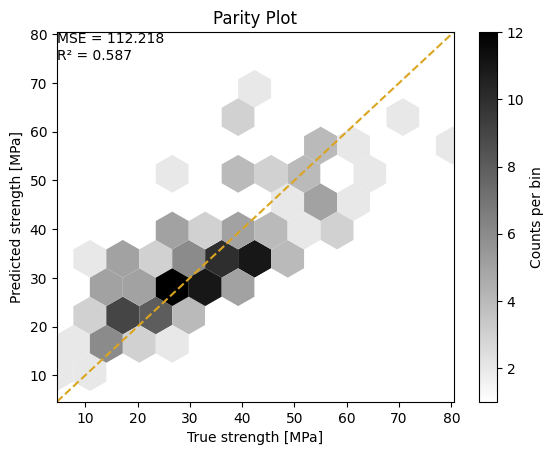

In [114]:
# Predictions
y_train_pred = X_train_d @ beta
y_test_pred  = X_test_d @ beta

# Visualization
parity_plot(y_test, y_test_pred)

## More compact option using scikit-learn

Intercept: 35.853540331653065
Coefficients: [ 0.         12.26577611  8.68078427  5.47164591 -3.65404759  1.59071011
  1.12470811  1.42448233  7.35888421]


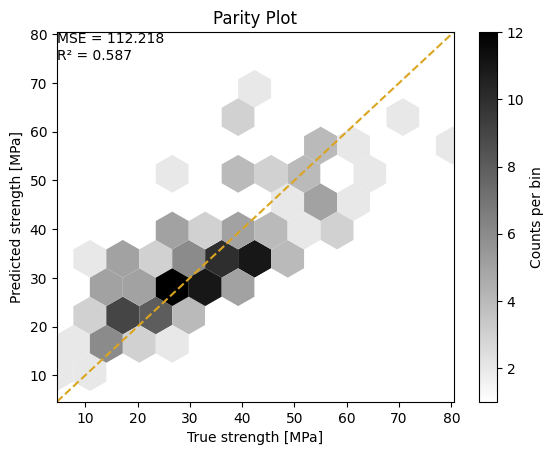

In [115]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_d, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_test_pred = model.predict(X_test_d)
parity_plot(y_test, y_test_pred)

## Results Interpretation:

#### What can we conclude about the performance of a linear regression model?

- MSE small → good fit
- R² close to 1 → model explains variance well